# Regresija

X - ulanzne karakteristike

y - ciljane brojcane vrijednosti

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.float_format', '{:,.2f}'.format)

In [19]:
df = pd.DataFrame({
    'area_m2': [35, 42, 50, 58, 65, 72, 80, 90, 100, 105, 115, 130, 110],
    'price_eur': [140000, 150000, 165000, 168000, 175000, 190000, 198000, 205000, 220000, 230000, 235000, 250000, 350000]
})

df

,area_m2,price_eur
0,35,140000
1,42,150000
2,50,165000
3,58,168000
4,65,175000
5,72,190000
6,80,198000
7,90,205000
8,100,220000
9,105,230000


Naknadno je u DataFrame `df` dodana zadnja vrijednost od 110 kvadrata i cijenom od 350000 EUR samo da poremeti linearnost i greska se nakon toga povecala, a R2 indeks udaljio od 1

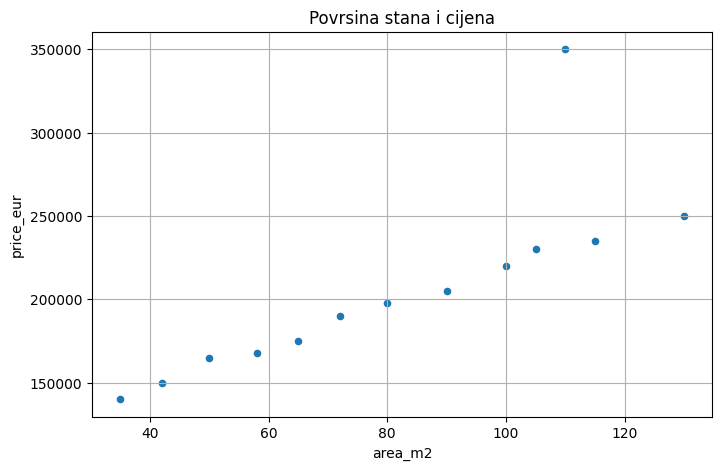

In [20]:
df.plot(
    kind='scatter',
    x='area_m2',
    y='price_eur',
    figsize=(8, 5),
    title='Povrsina stana i cijena'
)

plt.grid(True)

In [21]:
X = df[['area_m2']]
y = df['price_eur']

model_lin_reg = LinearRegression()
model_lin_reg.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [22]:
new_appartmnet = pd.DataFrame({'area_m2': [60]})
predicted_price = model_lin_reg.predict(new_appartmnet)[0]

f'Predvidena cijena apartmana od 60 m2 je {round(predicted_price, 2)} EUR.'

'Predvidena cijena apartmana od 60 m2 je 174764.47 EUR.'

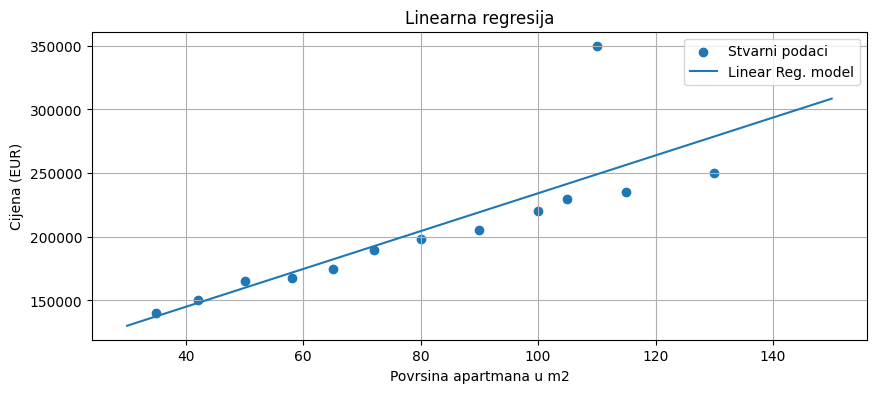

In [23]:
area_range = pd.DataFrame({'area_m2': np.linspace(30, 150, 100)})
pred_prices = model_lin_reg.predict(area_range)

plt.figure(figsize=(10, 4))
plt.scatter(df['area_m2'], df['price_eur'], label='Stvarni podaci')
plt.plot(area_range['area_m2'], pred_prices, label='Linear Reg. model')
plt.title('Linearna regresija')
plt.xlabel('Povrsina apartmana u m2')
plt.ylabel('Cijena (EUR)')
plt.legend()
plt.grid(True)
plt.show()

In [24]:
df['predicted prices'] = model_lin_reg.predict(X)

mae = mean_absolute_error(df['price_eur'], df['predicted prices'])
print(f'MEA: {mae:,.2f} EUR')
r2 = r2_score(df['price_eur'], df['predicted prices'])
print(f'R2 Score: {r2:,.2f}')

MEA: 16,984.41 EUR
R2 Score: 0.66


In [25]:
rng = np.random.default_rng(10)
n = 220
area_m2 = rng.normal(75, 22, n).clip(25, 160)
rooms = np.round(area_m2 / 28 + rng.normal(0, 0.5, n)).clip(1, 6).astype(int)
building_age = rng.integers(0, 80, n)
distance_center_km = rng.uniform(0.5, 18, n)
has_parking = rng.choice([0, 1], size=n, p=[0.45, 0.55])
price_eur = (65000 + area_m2*3100 + rooms*8500 - building_age*850 - distance_center_km*5200 + has_parking*18000 + rng.normal(0, 22000, n))

df_housing = pd.DataFrame({
    "area_m2": np.round(area_m2, 1),
    "rooms": rooms,
    "building_age": building_age,
    "distance_center_km": np.round(distance_center_km, 1),
    "has_parking": has_parking,
    "price_eur": np.round(price_eur, 0)
})

df_housing.head()

,area_m2,rooms,building_age,distance_center_km,has_parking,price_eur
0,50.70,2,38,10.80,1,"196,246.00"
1,59.00,2,31,16.00,1,"154,778.00"
2,57.80,2,51,6.40,1,"183,780.00"
3,80.90,3,76,2.00,0,"258,160.00"
4,69.50,3,58,6.30,1,"251,505.00"


In [26]:
df_housing.describe()

,area_m2,rooms,building_age,distance_center_km,has_parking,price_eur
count,220.00,220.00,220.00,220.00,220.00,220.00
mean,70.21,2.49,40.52,9.62,0.50,"226,605.21"
std,20.47,0.86,23.97,5.20,0.50,"81,908.80"
min,25.00,1.00,0.00,0.60,0.00,"4,769.00"
25%,57.02,2.00,18.75,5.50,0.00,"177,162.00"
50%,69.85,2.00,40.50,9.40,1.00,"225,203.00"
75%,84.03,3.00,62.25,14.20,1.00,"279,002.25"
max,131.10,5.00,79.00,18.00,1.00,"443,769.00"


In [27]:
df_housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   area_m2             220 non-null    float64
 1   rooms               220 non-null    int64  
 2   building_age        220 non-null    int64  
 3   distance_center_km  220 non-null    float64
 4   has_parking         220 non-null    int64  
 5   price_eur           220 non-null    float64
dtypes: float64(3), int64(3)
memory usage: 10.4 KB


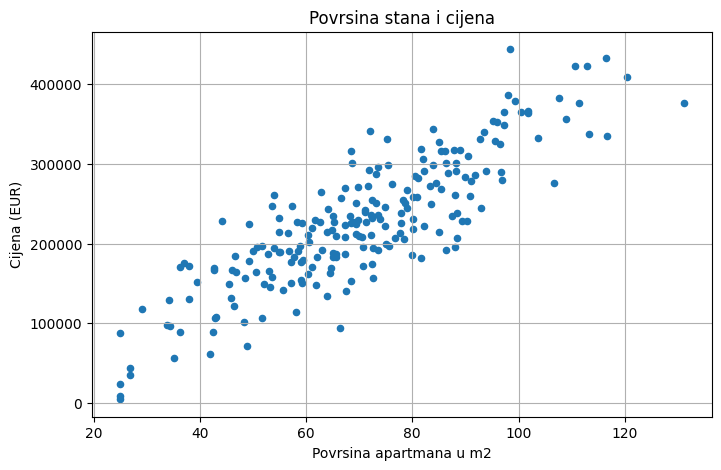

In [28]:
df_housing.plot(
    kind='scatter',
    x='area_m2',
    y='price_eur',
    figsize=(8, 5),
    title='Povrsina stana i cijena'
)

plt.xlabel('Povrsina apartmana u m2')
plt.ylabel('Cijena (EUR)')
plt.grid(True)

In [29]:
X = df_housing.drop(columns=['price_eur'])
y = df_housing['price_eur']

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [34]:
model_lin_reg_multi = LinearRegression()
model_lin_reg_multi.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [36]:
y_pred = model_lin_reg_multi.predict(X_test)

In [37]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MEA: {mae:,.2f} EUR')
print(f'R2 Score: {r2:,.2f}')

MEA: 18,772.49 EUR
R2 Score: 0.93


In [42]:
df_housing['price_eur'].median()

np.float64(225203.0)